# 32_01 — Simulación y preprocesamiento · Escenario R (recursión **par** + tendencia cúbica)

Escenario de **diagnóstico**: no es un Algoritmo del anexo. Existe para cubrir el
hueco que ninguno de los seis cubre —y que la corrida 31 tampoco cubre—: **un
generador en el que la curva no esté linealmente correlacionada con su propio
rezago**, de modo que toda referencia lineal quede en cero y la brecha contra el
óptimo sea medible.

$$Y_t = a\Big[\big((\Psi Y_{t-1})^2 + \delta^2\big)^{1/4} - c\Big] + \varepsilon_t,
\qquad X_t(\tau) = \mu(\tau) + b(t)\,g(\tau) + Y_t(\tau).$$

## Por qué el mapa es PAR y no $\mathrm{signo}(x)\lvert x\rvert^{1/2}$

La forma intuitiva de romper la linealidad **no la rompe**:
$\mathrm{signo}(x)\lvert x\rvert^{1/2}$ es una función *impar y monótona
creciente*, comprime el rango pero conserva el orden, de modo que
$\mathbb{E}[g(X)X]>0$ y el predictor lineal recoge casi todo. Medido sobre
400 000 pasos:

| recursión escalar | acf1 | $R^2$ mejor lineal | $R^2$ oráculo | brecha |
|---|---|---|---|---|
| $\mathrm{signo}(X)\lvert X\rvert^{1/2}$ | **+0.720** | **0.518** | 0.552 | 0.034 |
| $a(\lvert X\rvert^{1/2}-c)$ — **par** | **−0.004** | **0.000** | 0.266 | **0.266** |

Lo que anula la correlación lineal es la **paridad**, no la potencia: con $Y$
simétrico, $\mathrm{Cov}(\lvert Y\rvert, Y)=0$ *exactamente*, y toda la señal
queda fuera del alcance de cualquier método lineal. La raíz se conserva porque
es la que fija cuánto se aplana el mapa lejos del origen.

`delta` suaviza el valor absoluto ($\lvert z\rvert\approx\sqrt{z^2+\delta^2}$):
sin él el mapa tiene una **cúspide de raíz cuadrada** en cada cero de
$\Psi Y_{t-1}$, la curva deja de ser derivable en puntos que se mueven con $t$, y
eso lo pagaría la representación B-spline, no el modelo. Con $\delta>0$ el mapa
es $C^\infty$ y la no linealidad sigue intacta.

## Lo que este escenario permite y ningún otro

- **El MISE discrimina.** El mejor lineal sobre scores empata con la media
  incondicional ($R^2\approx 0$) mientras el oráculo llega a $\approx 0.45$: hay
  casi media varianza predecible que ninguna referencia lineal puede tocar. En el
  E1 esa brecha es cero por construcción, y en la corrida 31 también.
- **La ley condicional sigue siendo gaussiana** dado el pasado —la innovación no
  cambió—, de modo que lo que se pone a prueba es la capacidad de la mezcla para
  aproximar una **media condicional no lineal**, no su capacidad de representar
  colas o multimodalidad. Es un eje limpio y separado del de los Escenarios 3 y 4.

Paso **1 de 5** del ciclo `Python → MATLAB → Python`. El núcleo del operador
sigue siendo **gaussiano** y todo lo demás —esquema de observación,
$\lVert\Psi\rVert_{HS}=0.7$, innovación, priors, `mcmc_config`— es idéntico a la
corrida 30, para que lo único que cambie sea la recursión y la tendencia.

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: *este notebook** genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR
- 02: psbp_fd_iteracion.m muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento 
- 03, 04, 05: `32_03_convergencia` / `32_04_evaluacion` / `32_05_comparacion` 

Nota: Aca solo se simulan los objetos para entrenar en el  muestreador y para ajsutar el FAR en R. 

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [8]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario1, guardar_escenario,
    # Tendencia: misma parametrizacion que la familia con tendencia
    perfil_tendencia, forma_tendencia_lineal_en_tau,
    # Piezas de sim_comun con que se arma el generador de recursion par
    SalidaSimulacion, grilla_regular, pesos_trapezoidales, evaluar_media,
    matriz_operador_ar, matriz_covarianza_innovacion, factor_cholesky,
    generador_innovacion, semillas_replicas, aplicar_ruido_observacion,
    diagnostico_comun, norma_hilbert_schmidt,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [9]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario_R"
ESCENARIO_ID = 1      # Algoritmo k del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json
M_FPCA_LIST = (1, 2, 3)

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_R_1_r01
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3]
   M=1  ->  escenario_R_1_r01_m01
   M=2  ->  escenario_R_1_r01_m02
   M=3  ->  escenario_R_1_r01_m03


In [10]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_R_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_R_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_R_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_R_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_R_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_R_1_r01_m01
M=2  (escenario_R_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_R_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_R_1_r01_m02
  predict      -> C:\Users\56jua\Desktop\

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

`gamma`, `hs_norm`, `sigma_eps` y `ell` **no se tocan**: son los de la corrida 30.
$\Psi$ sigue siendo el operador integral de núcleo gaussiano y sigue calibrado a
$\lVert\Psi\rVert_{HS}=0.7$; lo que cambia es que su salida pasa por el mapa par
antes de sumarse a la innovación.

#### La recursión

| | |
|---|---|
| `RAZON_SENAL` | cociente entre la desviación $L^2$ de la parte determinista y la de la innovación. **Es el parámetro con significado**: `a` se *calibra* para alcanzarlo, en vez de fijarse a ciegas. Por encima de ~1.1 el punto fijo de la calibración deja de converger y `acf1` se despega de cero (medido: +0.27 con `RAZON_SENAL=1.2`); 0.9 está dentro de la zona estable y da la mayor brecha oráculo–lineal. |
| `DELTA_ABS` | suavizado del valor absoluto. Con 0 el mapa tiene una cúspide en cada cero de $\Psi Y_{t-1}$; con 0.25 es $C^\infty$ y la no linealidad no cambia. |
| `POTENCIA_MAPA` | el $1/2$ de $\lvert z\rvert^{1/2}$. Se implementa como $(z^2+\delta^2)^{p/2}$. |

`c` **no es un parámetro libre**: se calibra a $\mathbb{E}\lvert\Psi Y\rvert^{1/2}$
para que el mapa quede centrado. Sin eso $Y$ no sería simétrico, y la paridad
—que es todo el mecanismo— dejaría de anular la covarianza con el rezago.

#### La tendencia

Misma superposición determinista que la corrida 31, pero con la forma
`"potencia"` de exponente 3 en vez de `"cuadratica"`. El motivo es medido: la
cuadrática tiene una separación máxima respecto de su propia recta de
$\text{deriva}/4$ —la segunda más baja del catálogo— y con `deriva=3` sobre 800
puntos con ruido eso son 0.36 sd: **se lee como una recta**. Con exponente 3 y
`deriva=6` la curvatura sube a **1.43 sd** y la forma es inequívoca.

In [11]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 100     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 800    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25    # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau). Con nombre para que quede legible en el JSON.

    Es la media del Cuadro tab:ane_esquema del anexo, común a los seis
    escenarios. La corrida 11 usó 5 + 2 sin(2 pi tau): el FPCA centra con la
    media empírica y el efecto práctico es menor, pero la divergencia rompía
    la comparabilidad declarada y por eso esta corrida la corrige.
    """
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario1(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Operador autorregresivo
    gamma     = 0.3,
    hs_norm   = 0.7,
    # Innovación funcional
    sigma_eps = 1.0,
    ell       = 0.5,
)

# ── [CONFIG] Recursión PAR ───────────────────────────────────────
RAZON_SENAL   = 0.90   # sd_L2(parte determinista) / sd_L2(innovación); `a` se calibra
DELTA_ABS     = 0.25   # suavizado del valor absoluto
POTENCIA_MAPA = 0.50   # el exponente de |z|^p
N_PILOTO      = 4000   # longitud de la trayectoria con que se calibran a y c
N_IT_CALIB    = 8      # iteraciones del punto fijo (a y c se determinan mutuamente)
SEED_CALIB    = 999    # generador propio: calibrar no consume el de la simulación

# ── [CONFIG] Tendencia determinista superpuesta ────────────────────────
DERIVA          = 6.0          # desplazamiento total entre t=1 y t=T, en unidades de X
FORMA_TENDENCIA = "potencia"   # b(t)/deriva = u^p
EXPONENTE_TEND  = 3.0          # p; con 2 la forma se lee como una recta (ver §2.1)
INCLINACION     = 0.0          # g(tau) = 1 + c (tau - 1/2); cero = nivel puro

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<12}: {v}")
print(f"\n  {'razon_senal':<14}: {RAZON_SENAL}")
print(f"  {'delta_abs':<14}: {DELTA_ABS}")
print(f"  {'potencia_mapa':<14}: {POTENCIA_MAPA}")
print(f"\n  {'deriva':<14}: {DERIVA}")
print(f"  {'forma':<14}: {FORMA_TENDENCIA} (exponente {EXPONENTE_TEND})")
print(f"  {'inclinacion':<14}: {INCLINACION}")

  L           : 100
  T           : 800
  burn_in     : 200
  sigma_obs   : 0.25
  R           : 1
  seed        : 41232
  media_fn    : media_senoidal
  jitter      : 1e-10
  gamma       : 0.3
  hs_norm     : 0.7
  sigma_eps   : 1.0
  ell         : 0.5

  razon_senal   : 0.9
  delta_abs     : 0.25
  potencia_mapa : 0.5

  deriva        : 6.0
  forma         : potencia (exponente 3.0)
  inclinacion   : 0.0


### 2.2 El mapa, calibrado y dibujado

`a` y `c` se determinan mutuamente —`c` centra el mapa y `a` fija la escala de lo
que el mapa produce, que a su vez cambia el estado sobre el que se centra— de modo
que la calibración es un **punto fijo** y se itera. La celda imprime las últimas
iteraciones: si `a` no se estabiliza, `RAZON_SENAL` está en la zona inestable y hay
que bajarlo.

La trayectoria piloto usa un **generador propio** (`SEED_CALIB`), no el de la
simulación: así cambiar `RAZON_SENAL` no desplaza el consumo del generador y dos
corridas que difieran sólo en la tendencia comparten exactamente la misma
realización de $Y$.

Calibración (últimas 4 iteraciones del punto fijo):
   a = 3.8007   c = 0.7901
   a = 3.7810   c = 0.7947
   a = 3.8111   c = 0.7907
   a = 3.7721   c = 0.7948

  a = 3.7721   c = 0.7948   dispersión final = 1.03%


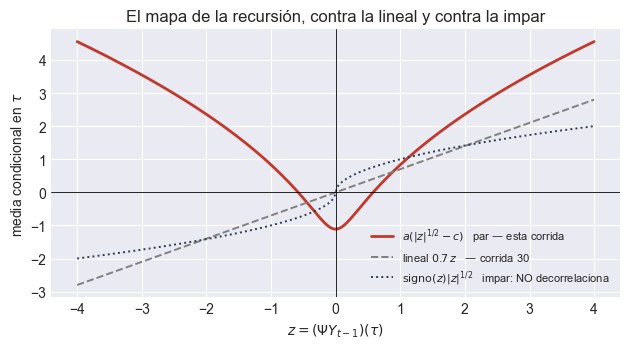

In [12]:
TAU  = grilla_regular(SIM_CFG.L)
W_Q  = pesos_trapezoidales(TAU)
MU   = evaluar_media(SIM_CFG.media_fn, TAU)
PSI  = matriz_operador_ar(TAU, SIM_CFG.gamma, SIM_CFG.hs_norm)
K_IN = matriz_covarianza_innovacion(TAU, SIM_CFG.sigma_eps, SIM_CFG.ell)
CH   = factor_cholesky(K_IN, SIM_CFG.jitter)


def mapa_par(z, a, c):
    """a * ( (z^2 + delta^2)^{p/2} - c ):  PAR en z, suave, raíz cuadrada con p=1/2.

    Par por construcción: `mapa_par(-z) == mapa_par(z)`. Ésa es toda la mecánica
    del escenario —con Y simétrico, Cov(|Y|, Y) = 0 y el mejor predictor lineal
    no tiene de dónde agarrarse— y por eso la celda lo verifica con un assert en
    vez de darlo por supuesto.
    """
    return a * (np.power(z * z + DELTA_ABS ** 2, POTENCIA_MAPA / 2.0) - c)


def trayectoria(a, c, T_, burn, rng):
    """Itera la recursión par y devuelve (Y, media condicional), ambas (T_, L)."""
    inn = generador_innovacion(CH, rng)
    Y = inn()
    for _ in range(burn):
        Y = mapa_par(PSI @ Y, a, c) + inn()
    Ys = np.empty((T_, SIM_CFG.L)); Ms = np.empty((T_, SIM_CFG.L))
    for t in range(T_):
        m = mapa_par(PSI @ Y, a, c)
        Y = m + inn()
        Ys[t] = Y; Ms[t] = m
    return Ys, Ms


def calibrar(razon, n_it=N_IT_CALIB, n_pilot=N_PILOTO, seed=SEED_CALIB):
    """Punto fijo sobre (a, c): c centra el mapa, a fija sd(m)/sd(eps) = razon."""
    sd_inn = float(np.sqrt(np.sum(np.diag(K_IN) * W_Q)))     # E||eps||_L2
    a, c, hist = 1.0, 1.0, []
    for _ in range(n_it):
        Ys, _ = trayectoria(a, c, n_pilot, 200, np.random.default_rng(seed))
        Z = Ys @ PSI.T
        c = float(np.mean(np.power(Z * Z + DELTA_ABS ** 2, POTENCIA_MAPA / 2.0)))
        _, Ms = trayectoria(a, c, n_pilot, 200, np.random.default_rng(seed))
        sd_m = float(np.sqrt(np.mean(np.sum(Ms ** 2 * W_Q, axis=1))))
        a = a * razon * sd_inn / max(sd_m, 1e-9)
        hist.append((a, c))
    return a, c, hist


A_MAPA, C_MAPA, _hist = calibrar(RAZON_SENAL)
print("Calibración (últimas 4 iteraciones del punto fijo):")
for _a, _c in _hist[-4:]:
    print(f"   a = {_a:.4f}   c = {_c:.4f}")
_disp = max(abs(x - A_MAPA) for x, _ in _hist[-4:]) / A_MAPA
print(f"\n  a = {A_MAPA:.4f}   c = {C_MAPA:.4f}   dispersión final = {_disp:.2%}")
assert _disp < 0.05, (
    f"El punto fijo de la calibración no converge (dispersión {_disp:.1%}): "
    f"RAZON_SENAL={RAZON_SENAL} está en la zona inestable. Bájelo.")

# La paridad no es un comentario: se verifica.
_z = np.linspace(-4, 4, 401)
assert np.allclose(mapa_par(_z, A_MAPA, C_MAPA), mapa_par(-_z, A_MAPA, C_MAPA)), (
    "El mapa dejó de ser par y con ello el escenario pierde su mecanismo.")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(_z, mapa_par(_z, A_MAPA, C_MAPA), color="#c0392b", lw=2.0,
        label=r"$a(|z|^{1/2}-c)$   par — esta corrida")
ax.plot(_z, SIM_CFG.hs_norm * _z, "--", color="0.5", lw=1.4,
        label=r"lineal $0.7\,z$   — corrida 30")
ax.plot(_z, np.sign(_z) * np.abs(_z) ** 0.5, ":", color="#2c3e50", lw=1.4,
        label=r"$\mathrm{signo}(z)|z|^{1/2}$   impar: NO decorrelaciona")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel(r"$z = (\Psi Y_{t-1})(\tau)$")
ax.set_ylabel(r"media condicional en $\tau$")
ax.set_title("El mapa de la recursión, contra la lineal y contra la impar")
ax.legend(fontsize=8); fig.tight_layout()
replicar_figura("00_mapa_recursion.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.3 Generación

Se persiste también la **media condicional verdadera**
(`internos["media_condicional"]`, de forma `(R, T, L)`). Es el **oráculo**: el techo
que ningún método puede superar, y sin él la cifra «el modelo recupera $x$ de la
brecha» no se puede calcular. Es lo mismo que hace el Escenario B y lo que a los
Escenarios 3 y 4 les faltó.

In [13]:
hijas, registro = semillas_replicas(SIM_CFG.seed, SIM_CFG.R)
REPLICA_IDX = REPLICA_ID - 1

_curvas = np.empty((SIM_CFG.R, SIM_CFG.T, SIM_CFG.L))
_obs    = np.empty((SIM_CFG.R, SIM_CFG.T, SIM_CFG.L))
_orac   = np.empty((SIM_CFG.R, SIM_CFG.T, SIM_CFG.L))
for _r, _sem in enumerate(hijas):
    _rng = np.random.default_rng(_sem)
    _Y, _M = trayectoria(A_MAPA, C_MAPA, SIM_CFG.T, SIM_CFG.burn_in, _rng)
    _curvas[_r] = MU + _Y
    _orac[_r]   = MU + _M                     # media condicional verdadera: el ORÁCULO
    _obs[_r]    = aplicar_ruido_observacion(_curvas[_r], SIM_CFG.sigma_obs, _rng)

salida = SalidaSimulacion(
    observaciones=_obs, curvas=_curvas, grilla=TAU, media=MU,
    semillas=registro, config=SIM_CFG,
    internos={"operador": PSI, "cov_innovacion": K_IN, "pesos_cuadratura": W_Q,
              "media_condicional": _orac,      # (R, T, L) — techo teórico
              "a_mapa": A_MAPA, "c_mapa": C_MAPA},
)
# `resumen_escenario_1` no aplica: verifica la estacionariedad de un FAR lineal y
# aquí la recursión no lo es. Se usa el diagnóstico común y §2.4 aporta lo propio.
salida.diagnostico = diagnostico_comun(salida)

X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape
Y_EST  = X_true - MU                         # componente estable, ANTES de la tendencia
M_ORAC = salida.internos["media_condicional"][REPLICA_IDX]

# ── Tendencia determinista ──────────────────────────────────────────
# Aditiva y determinista: no realimenta la dinámica, de modo que la componente Y
# es la misma serie que produciría esta corrida sin tendencia. Se suma a las DOS
# matrices —y al oráculo— porque es parte de la curva verdadera, no del ruido.
t_idx  = np.arange(1, T + 1)
b_t    = DERIVA * perfil_tendencia(t_idx, T, FORMA_TENDENCIA,
                                   exponente=EXPONENTE_TEND)              # (T,)
g_tau  = forma_tendencia_lineal_en_tau(INCLINACION)(grilla)               # (G,)
TEND   = np.outer(b_t, g_tau)                                             # (T, G)

X_raw  = X_raw  + TEND
X_true = X_true + TEND
M_ORAC = M_ORAC + TEND
salida.observaciones[REPLICA_IDX]  = X_raw
salida.curvas[REPLICA_IDX]         = X_true
salida.internos["media_condicional"][REPLICA_IDX] = M_ORAC
salida.internos["tendencia"]       = TEND
salida.internos["tendencia_b_t"]   = b_t
salida.internos["tendencia_g_tau"] = g_tau

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad común (calculado ANTES de sumar la tendencia:")
print("  `acf1_media` es el de la componente estable, no el del nivel.)")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")

Observadas (800, 100) · verdaderas (800, 100) · grilla (100,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2497   (nominal 0.25)

Control de calidad común (calculado ANTES de sumar la tendencia:
  `acf1_media` es el de la componente estable, no el del nivel.)
  n_replicas                       = 1
  n_curvas                         = 800
  n_puntos_grilla                  = 100
  todo_finito                      = True
  media_empirica_global            = -0.025111464293566123
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.747136122151486
  var_puntual_min                  = 1.3381488154583723
  var_puntual_max                  = 1.992383493721023
  acf1_media                       = 0.04680783500435779
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 27.954177954423777


### 2.4 ¿Vale la pena gastar MCMC?

Cuatro cifras deciden si el escenario tiene contenido, y las cuatro van con
`assert`. Se calculan sobre la componente **destendenciada**, porque una tendencia
de 4.8 desviaciones induce por sí sola toda la persistencia que uno quiera y
enmascararía el mecanismo:

- **`acf1_destendenciado`** — debe estar cerca de cero. Es el rasgo propio del
  escenario: la serie **parece ruido blanco** a cualquier diagnóstico lineal.
- **`r2_lineal_scores`** — el mejor predictor lineal sobre los primeros scores
  FPCA, ajustado en entrenamiento y evaluado **fuera de muestra**. Debe empatar
  con la media incondicional. Se mide fuera de muestra a propósito: con la curva
  entera en la grilla ($L=100$ regresores) el $R^2$ dentro de muestra está
  inflado por sobreajuste y el escenario parecería favorable sin serlo.
- **`r2_oraculo_scores`** — la media condicional verdadera, proyectada sobre las
  mismas autofunciones. Es el techo.
- **`brecha`** — la diferencia. **Es la única cifra del estudio que mide cuánto
  hay disponible para un método no lineal**, y en los seis Algoritmos del anexo
  vale prácticamente cero.

El diagnóstico de la tendencia va en el mismo bloque: `curvatura_en_sd` es la que
dice si la forma se distingue de una recta a ojo (por debajo de ~0.5 sd no), y
`desfase_en_sd` la que dice cuánto pierde vigencia el centrado del FPCA.

  a_mapa                     = 3.7721111486916916
  c_mapa                     = 0.7947823928674216
  razon_senal                = 0.9
  sd_componente_estable      = 1.335891178002023
  acf1_destendenciado        = 0.04680783500435779
  r2_lineal_scores           = -0.007539688410908019
  r2_oraculo_scores          = 0.4485608667073
  brecha                     = 0.456100555118208
  var_acum_1_2_3             = [0.829444766451622, 0.9741286965478247, 0.9964472457241695]
  forma_tendencia            = potencia p=3.0
  deriva                     = 6.0
  deriva_neta_en_sd          = 4.4913838034125515
  curvatura_en_sd            = 1.3451673420303552
  desfase_en_sd              = 2.4634888318510875
  b_en_T0_sobre_deriva       = 0.34244835607432905
  acf1_nivel_bruto           = 0.693125253105912
  estacionario               = False


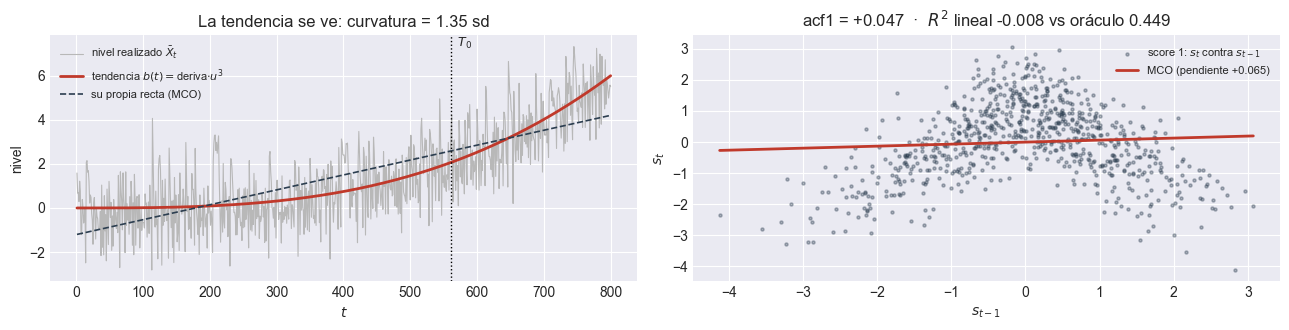

In [14]:
T0_ref = int(np.floor(PROP_TRAIN * T))
_gbar  = float(g_tau.mean())
_sd    = float(np.std(Y_EST))

# ── La recursión ───────────────────────────────────────────────
# acf1 puntual promedio sobre la componente estable (SIN tendencia)
_acf_l = []
for _l in range(G):
    _y = Y_EST[:, _l] - Y_EST[:, _l].mean()
    _acf_l.append(np.sum(_y[1:] * _y[:-1]) / np.sum(_y ** 2))
_acf1_dt = float(np.mean(_acf_l))

# FPCA rapido en L^2 sobre el bloque de entrenamiento, para medir el mejor lineal
# en el mismo espacio en que compiten los modelos del _05.
_M_DIAG = 3
_m0  = Y_EST[:T0_ref].mean(0)
_Cen = Y_EST[:T0_ref] - _m0                                             # (T0, G)
_C   = (_Cen * W_Q).T @ _Cen / T0_ref
_ev, _V = np.linalg.eigh(np.sqrt(W_Q)[:, None] * _C * np.sqrt(W_Q)[None, :])
_o   = np.argsort(_ev)[::-1]
_ev, _V = np.clip(_ev[_o], 0, None), _V[:, _o]
_Phi = _V / np.sqrt(W_Q)[:, None]                       # autofunciones ortonormales L^2
_S   = ((Y_EST - _m0) * W_Q) @ _Phi[:, :_M_DIAG]        # scores (T, M)
_So  = ((M_ORAC - TEND - MU - _m0) * W_Q) @ _Phi[:, :_M_DIAG]

_A, _B = _S[:-1], _S[1:]
_coef = np.linalg.lstsq(np.c_[np.ones(T0_ref), _A[:T0_ref]], _B[:T0_ref], rcond=None)[0]
_pred = np.c_[np.ones(len(_A) - T0_ref), _A[T0_ref:]] @ _coef
_sst  = float(np.sum((_B[T0_ref:] - _B[:T0_ref].mean(0)) ** 2))
_r2l  = 1.0 - float(np.sum((_B[T0_ref:] - _pred) ** 2)) / _sst
_r2o  = 1.0 - float(np.sum((_B[T0_ref:] - _So[1:][T0_ref:]) ** 2)) / _sst
_vr   = _ev / _ev.sum()

# ── La tendencia ────────────────────────────────────────────
_recta = np.polyval(np.polyfit(t_idx, b_t, 1), t_idx)
_niv   = X_true.mean(axis=1)


def _acf1(x):
    x = np.asarray(x, float) - np.mean(x)
    return float(np.sum(x[1:] * x[:-1]) / np.sum(x ** 2))


DIAG_ESCENARIO = {
    # recursion
    "a_mapa":                 float(A_MAPA),
    "c_mapa":                 float(C_MAPA),
    "razon_senal":            float(RAZON_SENAL),
    "sd_componente_estable":  _sd,
    "acf1_destendenciado":    _acf1_dt,
    "r2_lineal_scores":       float(_r2l),
    "r2_oraculo_scores":      float(_r2o),
    "brecha":                 float(_r2o - _r2l),
    "var_acum_1_2_3":         [float(_vr[0]), float(_vr[:2].sum()), float(_vr[:3].sum())],
    # tendencia
    "forma_tendencia":        f"{FORMA_TENDENCIA} p={EXPONENTE_TEND}",
    "deriva":                 float(DERIVA),
    "deriva_neta_en_sd":      float((b_t[-1] - b_t[0]) * _gbar / _sd),
    "curvatura_en_sd":        float(np.max(np.abs(b_t - _recta)) * _gbar / _sd),
    "desfase_en_sd":          float((b_t[T0_ref:].mean() - b_t[:T0_ref].mean())
                                    * _gbar / _sd),
    "b_en_T0_sobre_deriva":   float(b_t[T0_ref - 1] / DERIVA),
    "acf1_nivel_bruto":       _acf1(_niv),
    "estacionario":           False,
}
for k, v in DIAG_ESCENARIO.items():
    print(f"  {k:26s} = {v}")

assert abs(DIAG_ESCENARIO["acf1_destendenciado"]) < 0.15, (
    "La componente estable sigue linealmente correlacionada con su rezago: el "
    "mecanismo del escenario no está funcionando. Revise la calibración de c.")
assert DIAG_ESCENARIO["r2_lineal_scores"] < 0.10, (
    "El mejor predictor lineal supera a la media incondicional: la referencia "
    "lineal no muere y el escenario no discrimina más que el E1.")
assert DIAG_ESCENARIO["r2_oraculo_scores"] > 0.15, (
    "El oráculo apenas predice: no hay señal que un método no lineal pueda "
    "recuperar y no tiene sentido gastar MCMC.")
assert DIAG_ESCENARIO["deriva_neta_en_sd"] > 1.0, (
    "La tendencia no supera una desviación de la componente estable: no se vería "
    "en el histórico. Suba DERIVA.")
assert DIAG_ESCENARIO["curvatura_en_sd"] > 0.5, (
    "La tendencia se lee como una recta. Suba EXPONENTE_TEND o DERIVA: fue "
    "exactamente el problema de la corrida 31.")

# ── Figura ─────────────────────────────────────────────────
_mu_bar = float(np.mean(MU))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].plot(t_idx, _niv, color="0.72", lw=0.8, label=r"nivel realizado $\bar{X}_t$")
axes[0].plot(t_idx, b_t * _gbar + _mu_bar, color="#c0392b", lw=2.0,
             label=rf"tendencia $b(t)=$deriva$\cdot u^{{{EXPONENTE_TEND:.0f}}}$")
axes[0].plot(t_idx, _recta * _gbar + _mu_bar, "--", color="#2c3e50", lw=1.2,
             label="su propia recta (MCO)")
axes[0].axvline(T0_ref + 0.5, color="k", lw=1.0, ls=":")
axes[0].text(T0_ref + 0.5, axes[0].get_ylim()[1], "  $T_0$", va="top", fontsize=9)
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("nivel")
axes[0].set_title(f"La tendencia se ve: curvatura = "
                  f"{DIAG_ESCENARIO['curvatura_en_sd']:.2f} sd")
axes[0].legend(fontsize=8)

axes[1].scatter(_S[:-1, 0], _S[1:, 0], s=5, alpha=0.35, color="#2c3e50",
                label="score 1: $s_{t}$ contra $s_{t-1}$")
_xs = np.linspace(_S[:, 0].min(), _S[:, 0].max(), 200)
_bb = np.polyfit(_S[:-1, 0], _S[1:, 0], 1)
axes[1].plot(_xs, np.polyval(_bb, _xs), color="#c0392b", lw=2.0,
             label=f"MCO (pendiente {_bb[0]:+.3f})")
axes[1].set_xlabel("$s_{t-1}$"); axes[1].set_ylabel("$s_t$")
axes[1].set_title(f"acf1 = {_acf1_dt:+.3f}  ·  "
                  f"$R^2$ lineal {_r2l:+.3f} vs oráculo {_r2o:.3f}")
axes[1].legend(fontsize=8)
fig.tight_layout()
replicar_figura("05_diagnostico_escenario.png", PATHS_POR_M, fig=fig)
plt.show()

In [15]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "escenario":     DIAG_ESCENARIO,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_R_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_R_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_R_1_r01_m03\escenario_1.npz


### 2.5 Visualización de los datos

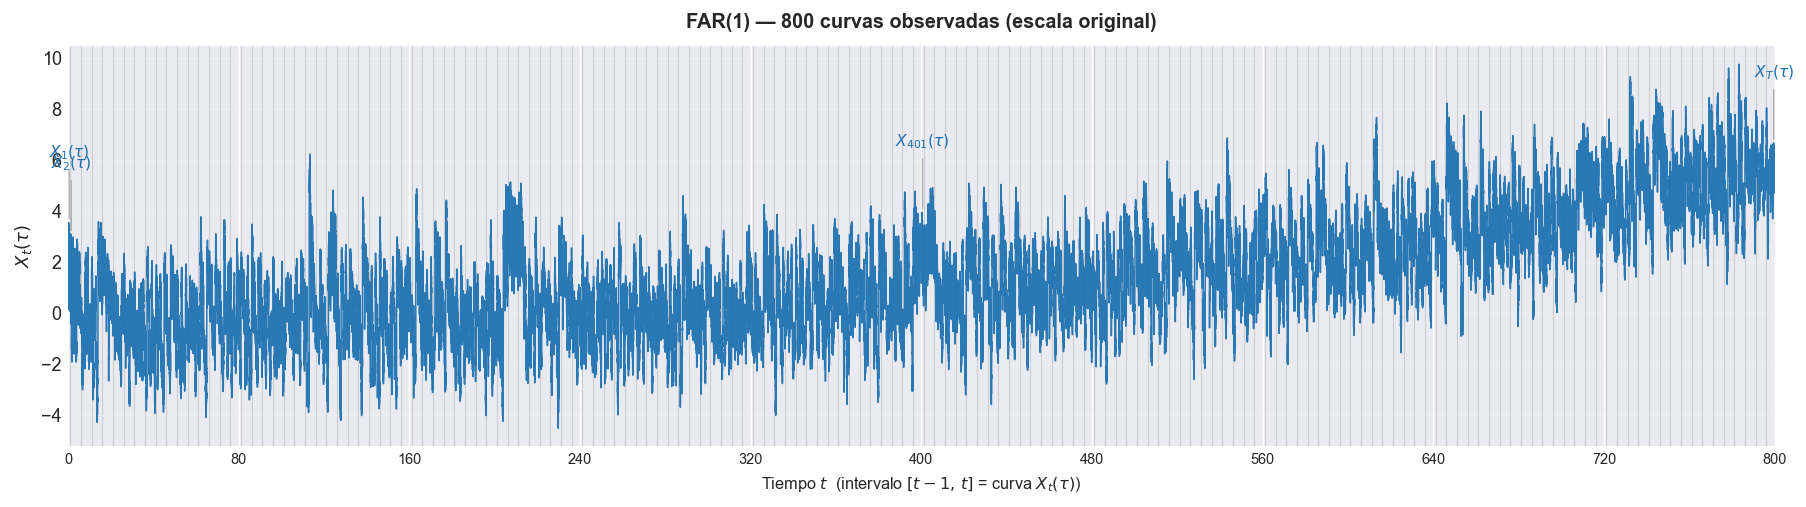

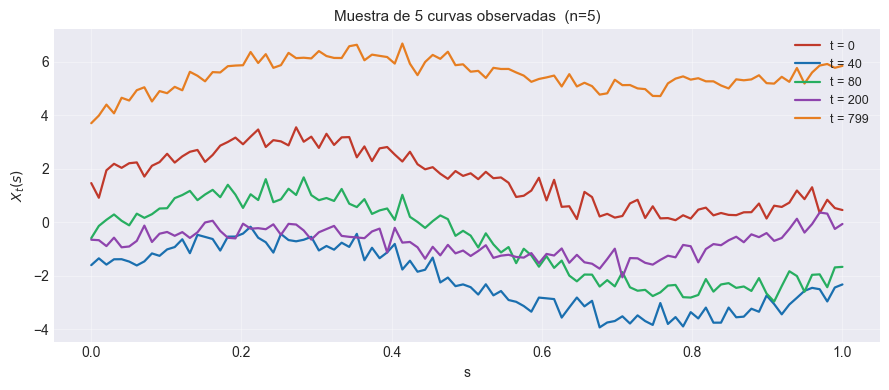

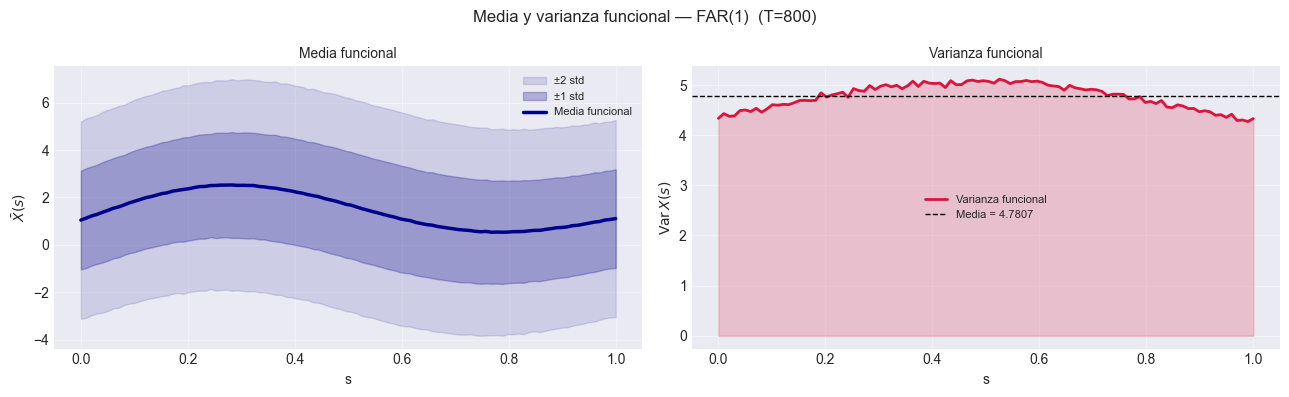

In [16]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — FAR(1)")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

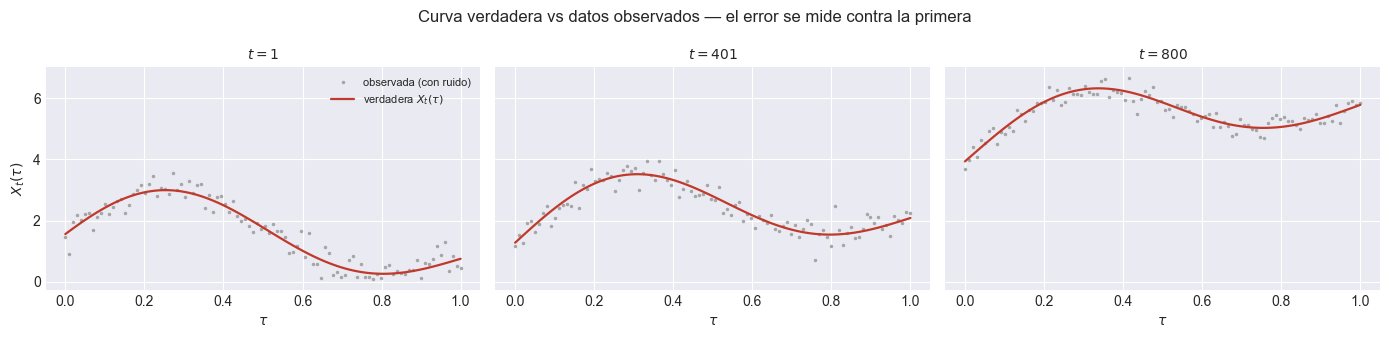

In [17]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

### 2.6 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [18]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 3 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 3 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 3 directorios)


### 2.7 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [19]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 560]      → (560, 100)
prueba        : t ∈ [561, 800]  → (240, 100)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,83.4853%,0.597493,1.004880,0.386450
1,3,2,87.7971%,0.516466,0.799401,0.291470
2,4,2,96.4591%,0.280889,0.411726,0.086346
3,5,2,97.0409%,0.257129,0.327485,0.073688
4,6,2,97.2531%,0.247763,0.306626,0.069865
5,7,2,97.3352%,0.244023,0.303016,0.069243
6,8,2,97.3943%,0.241288,0.296759,0.069186
7,9,2,97.4346%,0.239422,0.295631,0.069624
8,10,2,97.4683%,0.237811,0.293680,0.070244
9,11,2,97.4984%,0.236389,0.292540,0.070977



GCV mínimo → n_basis=6, order=4  (var retenida 97.3537%)


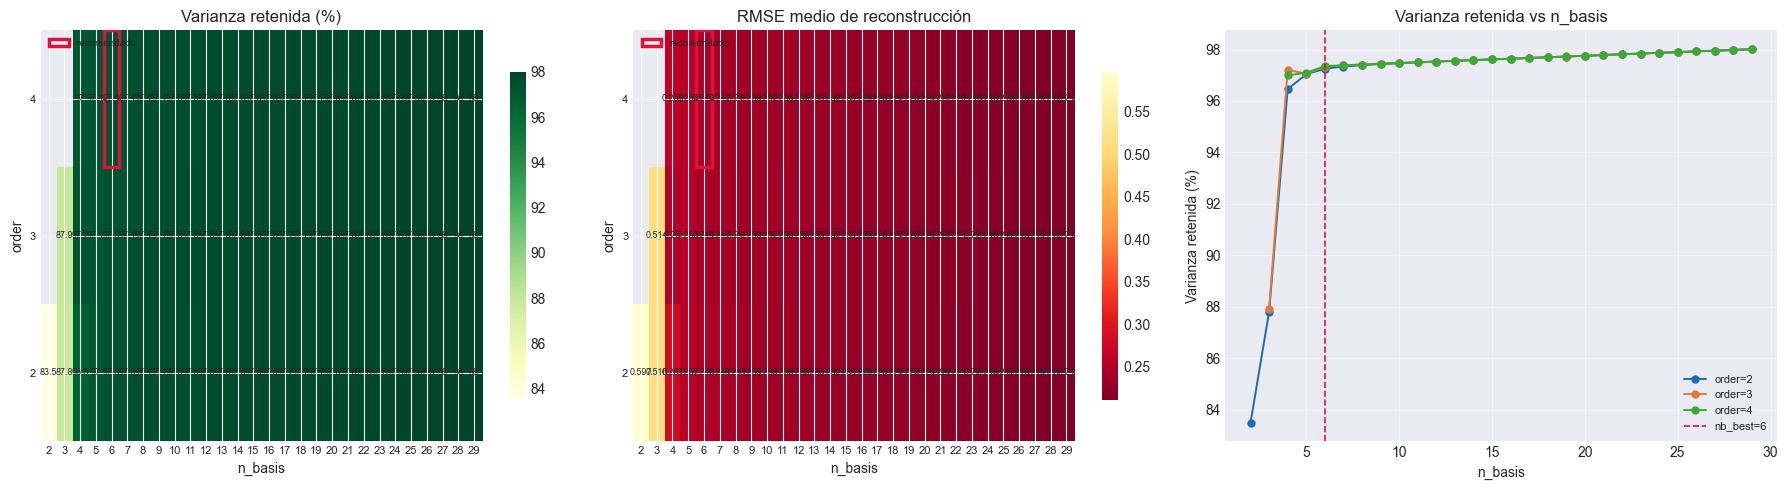

In [20]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=6, order=4
Sugerido GCV : n_basis=6, order=4   (coinciden)
THETA (800, 6)  (train=560, test=240)


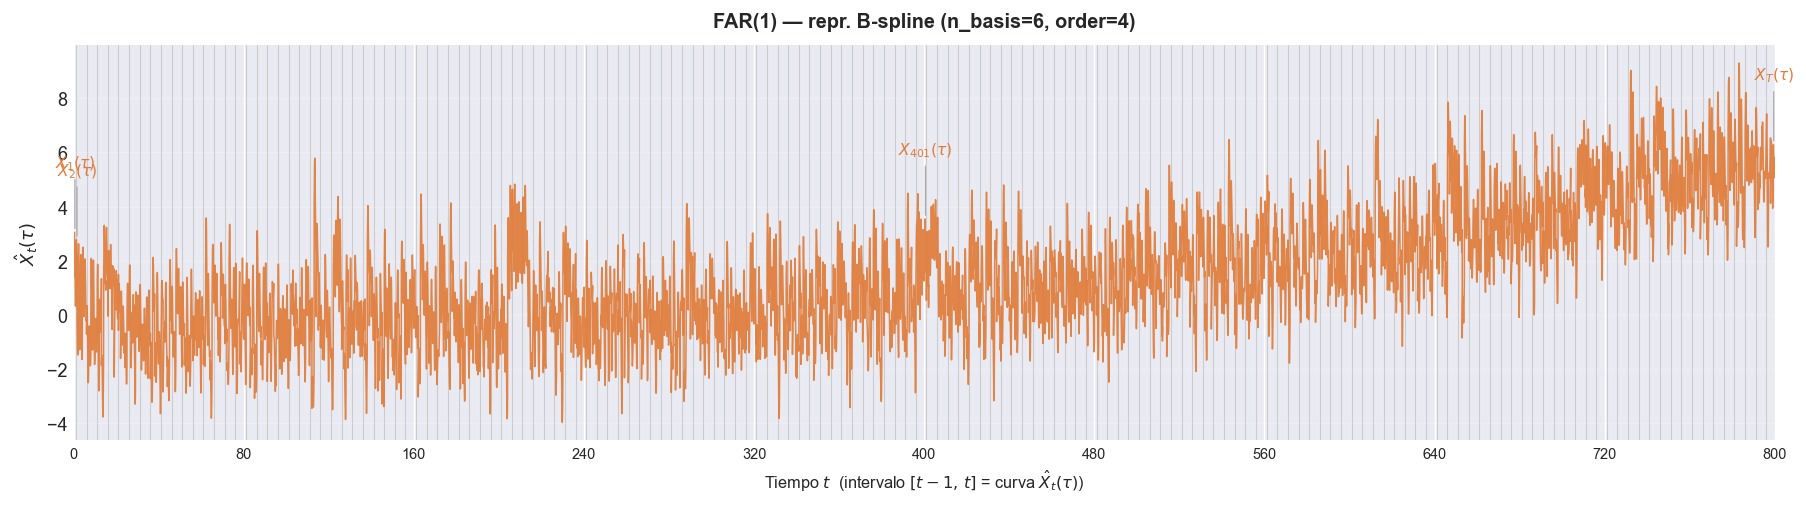

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 3 directorios)


In [21]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [22]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 6
  K                                  = 6
  n_ajuste                           = 560
  cond_W                             = 2.790e+01
  err_ortonormalidad_L2              = 2.665e-15
  err_ortonormalidad_gram            = 2.442e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.927e-16
  err_media_scores_rel               = 2.304e-15
  err_var_scores_vs_lambda           = 1.332e-15
  err_var_scores_vs_lambda_rel       = 8.261e-14
  err_correlacion_lag0               = 3.576e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,1.8856e+00,85.8696%,85.8696%,+0.273
1,2,2.5982e-01,11.8323%,97.7019%,+0.003
2,3,4.3977e-02,2.0027%,99.7047%,+0.032
3,4,4.6310e-03,0.2109%,99.9156%,-0.029
4,5,1.1982e-03,0.0546%,99.9701%,-0.053
5,6,6.5624e-04,0.0299%,100.0000%,-0.064



K disponibles: 6   ·   sugerencia (var ≥ 95%): M = 2
  M=1: var. acum = 85.8696%  ·  sensibilidad
  M=2: var. acum = 97.7019%  ·  regla del 95 %
  M=3: var. acum = 99.7047%  ·  sensibilidad


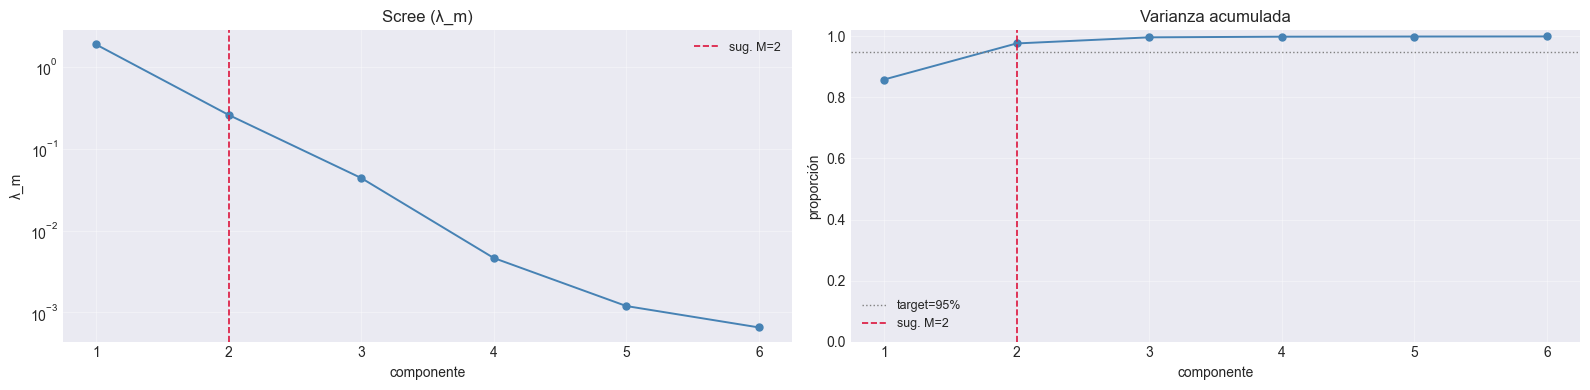

In [23]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido: no hay más de K componentes que retener.
# Con mu = sin(2 pi tau) el GCV eligió una base corta, de modo que los puntos
# altos del barrido caen en componentes que son en buena medida artefacto de
# esa base y no direcciones del proceso. Se advierte, no se oculta.
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

| Bloque | Qué hace |
|---|---|
| §4.1 | `set_M(M)` y scores; contraste con la regla del 95 % |
| §4.2 | estandarización (**sólo train**) y artefactos FPCA |
| §4.3 | diagnóstico de rezagos sobre el bloque de entrenamiento |
| §4.4 | orden AR y construcción de los datasets |
| §4.5 | hiperparámetros y `mcmc_config` — el contrato con MATLAB |
| §4.6 | `eval_config`, líneas base y `verificar_contrato` |

In [24]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    # M se declara en la celda [BARRIDO] de §1.1 porque forma parte del
    # EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Aquí sólo se
    # consume y se contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Estandarización ------------------------------------------------
    # Se ajusta SÓLO con train y registra n_ajuste para que esa disciplina sea
    # auditable desde el artefacto y no una promesa del notebook. La ausencia
    # de fuga en el FPCA ya es propiedad de la clase (su fit vio sólo train);
    # aquí no se reajusta nada, sólo se trunca.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    SCORES_STD       = scores_standardizer.transform(SCORES)
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}")
    print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (~0)")
    print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (~0)")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi estandarizados"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    # Los rezagos del primer origen de prueba vienen del final del bloque de
    # entrenamiento: son observaciones pasadas disponibles en cada origen, de
    # modo que su uso es el condicionamiento de la predicción a h=1, no fuga.
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "standardized_zscore_ddof0",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC: el contrato con MATLAB -----------------
    # psbp_fd_iteracion.m lee estos valores del JSON y no los tiene escritos a
    # mano, incluida seed_base. Ojo con la doble acepción de M: dentro de
    # mcmc_config es el tamaño de la grilla de localización G* del
    # stick-breaking, NO el número de componentes FPCA; N es el truncamiento
    # del número de átomos.
    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        tipos = [_clasificar(nm, k) for nm in cov_names]
        vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "apij": vals[:, 0], "bpij": vals[:, 1],
            "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
        print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            marca = "  <" if _clasificar(nm, k) == "own_lag1" else ""
            print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
                  f"{a/(a+b):>7.3f}{marca}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "standardized_zscore_ddof0",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    # objetivo_evaluacion y modo_residuo se declaran aquí porque cambian el
    # significado de toda la evaluación y no deben quedar como una decisión
    # implícita del notebook _04. Son idénticos entre puntos del barrido, y
    # 32_04 lo exige con assert.
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "standardized_zscore_ddof0",
        # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
        #   curva_verdadera + modo_residuo "ninguno" => la banda cubre la curva
        #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau). Lo
        #   que queda fuera es truncamiento FPCA puro, sin el ruido de medición.
        "objetivo_evaluacion": "curva_verdadera",
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
        "metrics_curvas": ["MISE", "RMSE_funcional"],
        "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_true, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva VERDADERA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

N_LAGS      : 1
MCMC_CONFIG : {'nsim': 2500, 'burn': 500, 'N': 35, 'M': 35}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (2500 - 500) x 2 = 4000

M = 1   ·   escenario_R_1_r01_m01
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 85.8696%
[train] max|media xi| = 1.02e-16   (~ 0)
[test]  max|media xi| = 3.296
[test]  var xi / lambda = [1.405]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 1)
  [train] max|media| = 2.54e-17  (~0)
  [train] max|std-1| = 1.11e-16  (~0)
  [test]  media = [-2.402]
  [test]  std   = [1.184]

[functional] artefactos FPCA · cond_W = 2.790e+01


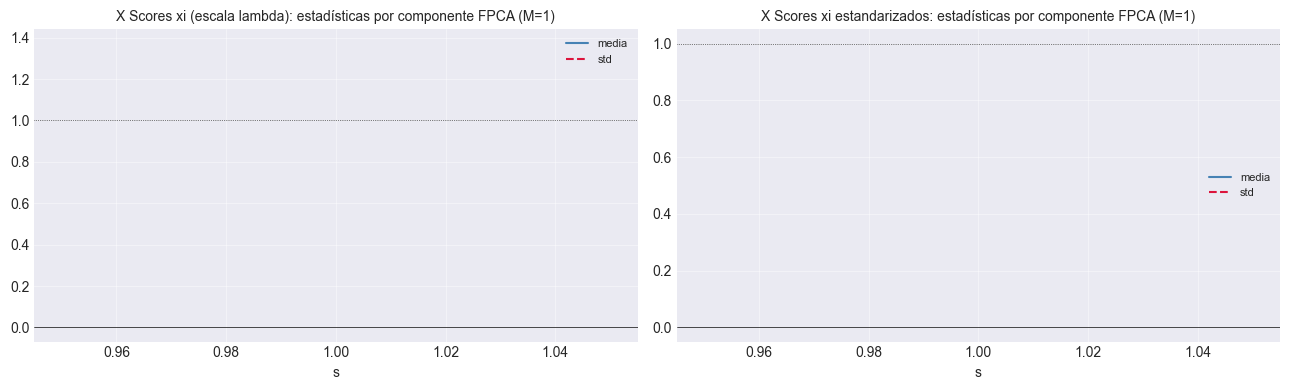

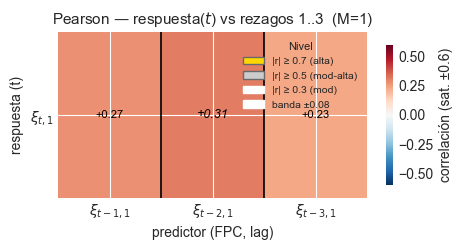

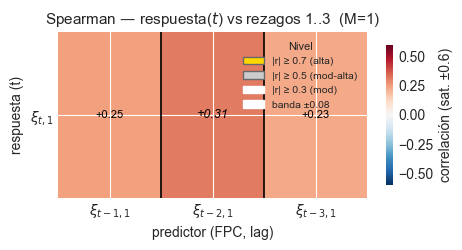

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (559, 2) · test (240, 2)

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_R_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,240.0000,2.6781,2.6781,-4.1168,13.8786,3.7254
persistencia_lag1,240.0000,1.1955,1.1955,-0.0195,3.0900,1.7578


contrato_ok = True   (M=1, K=6, T0=560, n_components=1)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_R_1_r01_m02
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 2   (coincide con la regla)
M = 2   var. explicada = 97.7019%
[train] max|media xi| = 1.93e-16   (~ 0)
[test]  max|media xi| = 3.296
[test]  var xi / lambda = [1.405 0.917]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 2)
  [train] max|media| = 1.14e-16  (~0)
  [train] max|std-1| = 5.55e-16  (~0)
  [test]  media = [-2.402 -0.04 ]
  [test]  std   = [1.184 0.956]

[functional] artefactos FPCA · cond_W = 2.790e+01


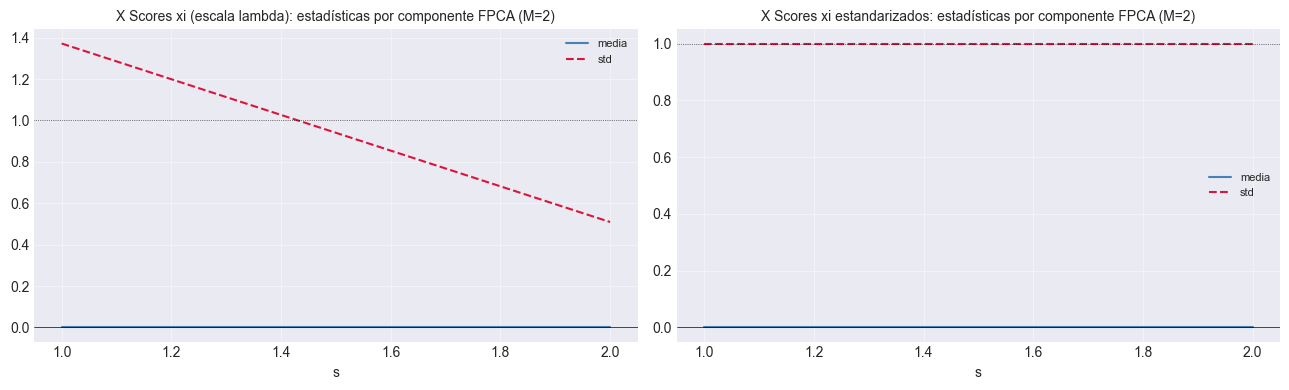

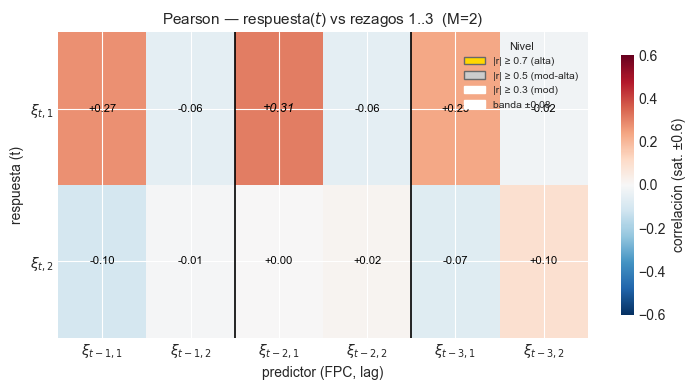

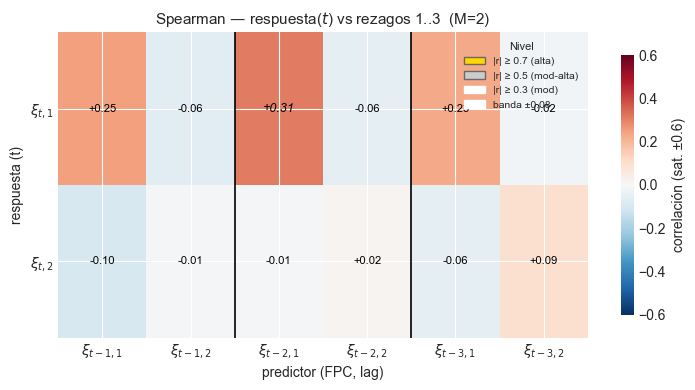

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (559, 3) · test (240, 3)
  fpc_2: train (559, 3) · test (240, 3)

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_R_1_r01_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,240.0000,2.6781,0.9572,1.8177,-2.0593,13.8786,3.7254
persistencia_lag1,240.0000,1.1955,1.3999,1.2977,-0.5810,3.3601,1.8331


contrato_ok = True   (M=2, K=6, T0=560, n_components=2)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_R_1_r01_m03
M(95 %) según la regla : 2   (K disponible = 6)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 99.7047%
[train] max|media xi| = 1.93e-16   (~ 0)
[test]  max|media xi| = 3.296
[test]  var xi / lambda = [1.405 0.917 1.27 ]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 3)
  [train] max|media| = 1.14e-16  (~0)
  [train] max|std-1| = 5.55e-16  (~0)
  [test]  media = [-2.402 -0.04  -1.597]
  [test]  std   = [1.184 0.956 1.126]

[functional] artefactos FPCA · cond_W = 2.790e+01


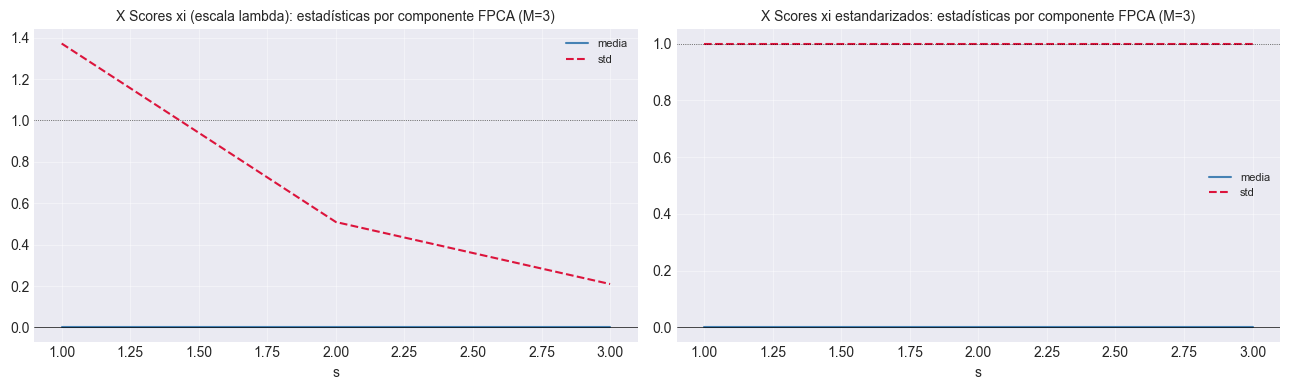

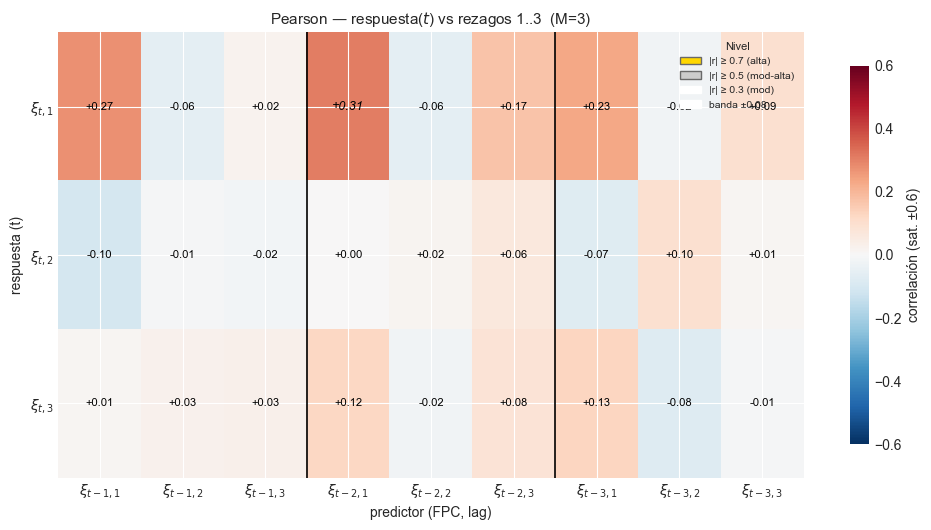

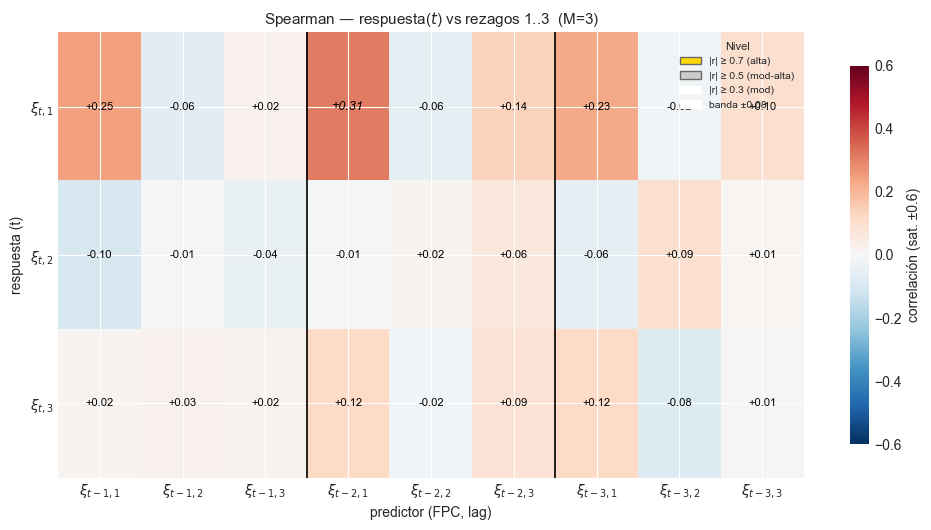

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (559, 4) · test (240, 4)
  fpc_2: train (559, 4) · test (240, 4)
  fpc_3: train (559, 4) · test (240, 4)

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo         

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,240.0000,2.6781,0.9572,1.9536,1.8630,-2.0435,13.8786,3.7254
persistencia_lag1,240.0000,1.1955,1.3999,1.3348,1.3101,-0.5227,3.2703,1.8084


contrato_ok = True   (M=3, K=6, T0=560, n_components=3)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True


In [25]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 1
MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": 35, "M": 35}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [26]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 32_03, 32_04 y 32_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_R_1_r01_m01,85.8696%,6,False,1,1,True
2,escenario_R_1_r01_m02,97.7019%,6,True,2,2,True
3,escenario_R_1_r01_m03,99.7047%,6,False,3,3,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2 3]  (el mismo de 32_03, 32_04 y 32_05)
